# Exploratory Data Anlysis on BND Ticker

In [1]:
import pandas as pd
import matplotlib as plt
import numpy as np

import sys
import os
sys.path.append(os.path.abspath('../'))
from src.data_preprocessing import (
    scrapeData,
    price_movingAvg,
    daily_return
)

In [2]:
df = scrapeData('BND', '2015-01-01','2026-06-30','1d')

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head(3)

Price,Close,High,Low,Open,Volume
Ticker,BND,BND,BND,BND,BND
Date,,,,,
2015-01-02,59.405430,59.434181,59.240113,59.247302,2218800
2015-01-05,59.577923,59.599485,59.441357,59.470108,5820100
2015-01-06,59.750454,59.930144,59.678579,59.678579,3887600


In [4]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,BND,BND,BND,BND,BND
count,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,66.503053,66.600149,66.404061,66.505297,4.653786e+06
std,4.713607,4.719859,4.705621,4.713244,3.017704e+06
min,58.729237,58.801812,58.692934,58.758282,0.000000e+00
25%,62.478096,62.536688,62.405153,62.472868,2.233700e+06
50%,65.728390,65.852782,65.596767,65.712494,4.280650e+06
75%,70.689125,70.843014,70.549777,70.688882,6.246475e+06
max,74.832909,74.924869,74.799456,74.891422,3.396300e+07


In [5]:
df.dtypes

Price   Ticker
Close   BND       float64
High    BND       float64
Low     BND       float64
Open    BND       float64
Volume  BND         int64
dtype: object

In [6]:
print(df.index)

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18',
               '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25',
               '2026-06-26', '2026-06-29'],
              dtype='datetime64[s]', name='Date', length=2888, freq=None)


In [7]:
#STRUCTURAL SUMMARY
print(f"Data Timeframe: {df.index.min()} to {df.index.max()}")
print(f"Total Trading Days: {len(df)}")
print(f"Any missing values?\n{df.isnull().sum()}\n")

Data Timeframe: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
Total Trading Days: 2888
Any missing values?
Price   Ticker
Close   BND       0
High    BND       0
Low     BND       0
Open    BND       0
Volume  BND       0
dtype: int64



## Check for Null Values

In [8]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, BND)   2888 non-null   float64
 1   (High, BND)    2888 non-null   float64
 2   (Low, BND)     2888 non-null   float64
 3   (Open, BND)    2888 non-null   float64
 4   (Volume, BND)  2888 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 135.4 KB


### TIME-SERIES STATIONARITY

In [9]:
# Calculate daily log returns to make the data stationary for models
df['Returns'] = df['Close'].pct_change()
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))

In [10]:
# Run the Augmented Dickey-Fuller test to prove returns are stationary
from statsmodels.tsa.stattools import adfuller
adf_stat, p_val, *_, = adfuller(df['Log_Returns'].dropna())
print(f"ADF Statistic: {adf_stat:.4f}")
print(f"p-value: {p_val:.4f} (If < 0.05, your returns data is stationary and safe for ML)")

ADF Statistic: -15.2537
p-value: 0.0000 (If < 0.05, your returns data is stationary and safe for ML)


### VOLATILITY & RISK DISTRIBUTION

In [11]:
print(f"Daily Volatility (Std Dev of Returns): {df['Returns'].std():.4f}")
print(f"Skewness: {df['Returns'].skew():.4f} (Negative = more frequent sharp drops)")
print(f"Kurtosis: {df['Returns'].kurt():.4f} (> 3 means 'fat tails' / extreme shock risk)")

Daily Volatility (Std Dev of Returns): 0.0033
Skewness: -0.9172 (Negative = more frequent sharp drops)
Kurtosis: 36.4926 (> 3 means 'fat tails' / extreme shock risk)


### TRADING VOLUME ANOMALIES

In [12]:
# 1. Properly flatten the MultiIndex if it exists as a string tuple or an actual MultiIndex
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
else:
    # If it already got turned into string tuples like "('Volume', 'TSLA')", extract just the first word
    df.columns = [col.split("'")[1] if "('" in str(col) else str(col) for col in df.columns]

In [13]:
# Quick sanity check print to make sure columns are clean names
print("Cleaned Columns:", list(df.columns))

Cleaned Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'Returns', 'Log_Returns']


In [14]:
# 2. Extract Volume safely as a 1D Series now that the name is exactly 'Volume'
volume_series = df['Volume'].squeeze()

In [15]:
# 3. Calculate your baseline metrics
df['Vol_SMA20'] = volume_series.rolling(window=20).mean()
df['Vol_Anomaly_Ratio'] = volume_series / df['Vol_SMA20']

In [16]:
# 4. Filter and display
huge_volume_days = df[df['Vol_Anomaly_Ratio'] > 3.0]
print(f"\nNumber of days where trading volume was 3x+ higher than the monthly average: {len(huge_volume_days)}")


Number of days where trading volume was 3x+ higher than the monthly average: 10


In [17]:
# 1. Force the columns to be completely flat, clean strings
df.columns = [str(col) for col in df.columns]

# 2. Extract Volume explicitly as a 1D Series (squeezing any remaining multi-dimensions)
volume_series = df['Volume'].squeeze()

# 3. Recalculate your baseline metrics safely
df['Vol_SMA20'] = volume_series.rolling(window=20).mean()
df['Vol_Anomaly_Ratio'] = volume_series / df['Vol_SMA20']

# 4. Filter and display
huge_volume_days = df[df['Vol_Anomaly_Ratio'] > 3.0]
print(f"Number of days where trading volume was 3x+ higher than the monthly average: {len(huge_volume_days)}")

Number of days where trading volume was 3x+ higher than the monthly average: 10


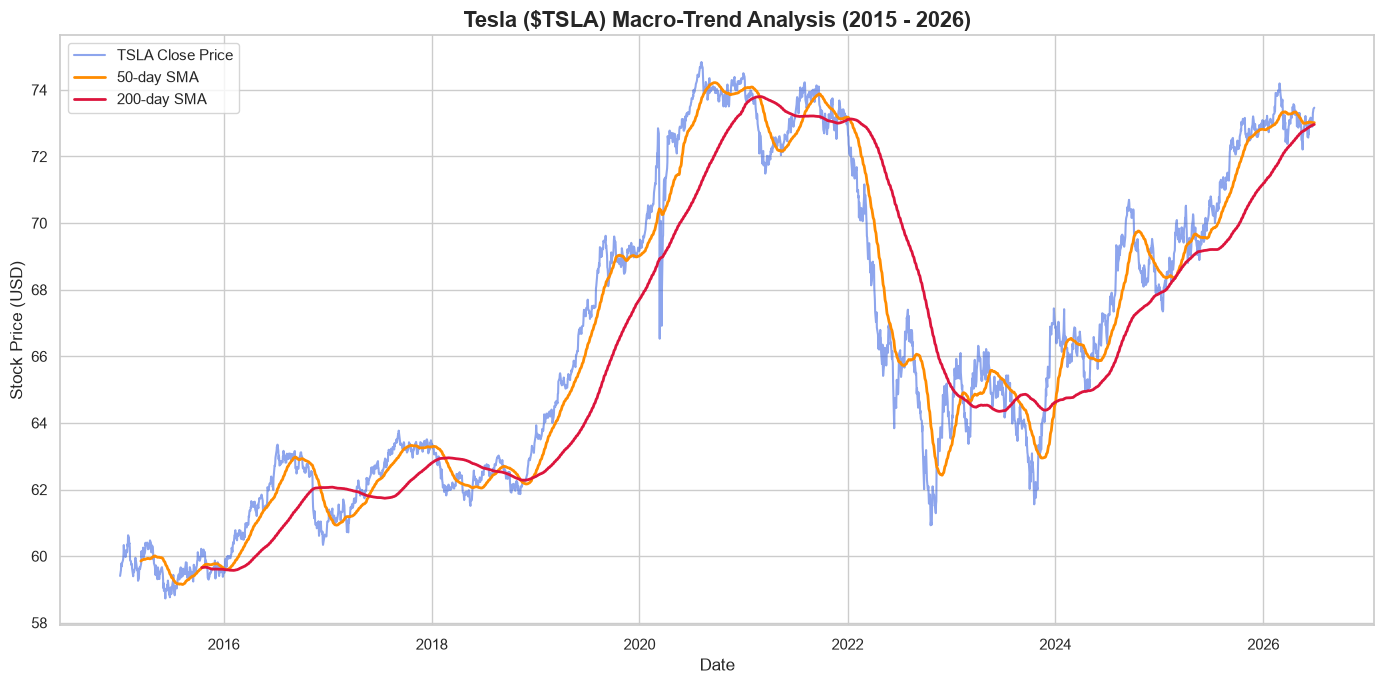

In [18]:
price_movingAvg(df)

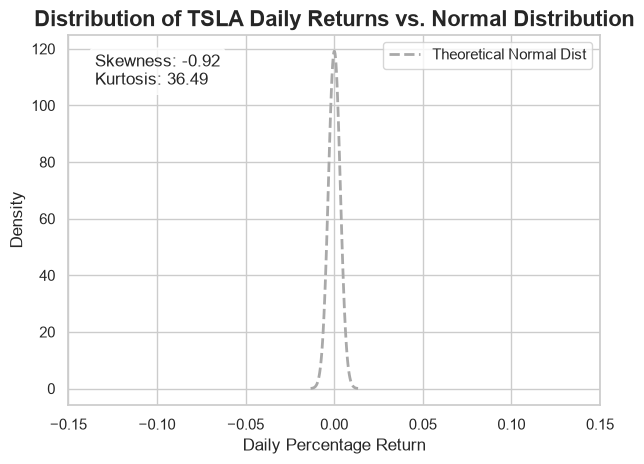

In [19]:
daily_return(df)